# EDA 01 — Chamados de árvores no 1746
**Projeto de extensão: Ciência de Dados para Cidades Inteligentes**

Este é o meu caderno de **análise exploratória de dados (EDA)**. EDA é a etapa em que a gente conhece os dados antes de tirar qualquer conclusão: quantas linhas existem, o que cada coluna quer dizer, o que está faltando e o que parece estranho.

Antes de juntar as bases, vou olhar **uma tabela de cada vez**, porque cada uma é de um tipo diferente:

| Tabela | O que cada linha representa | Tipo de tabela |
|---|---|---|
| Chamados do 1746 | um chamado aberto por um cidadão | tabela de **eventos** |
| Chuva (Alerta Rio) | uma medição de uma estação, a cada 15 minutos | **série temporal** de sensores |
| Logradouros | um **trecho** de rua | **cadastro** (tabela de referência) |
| Bairros | um bairro | **cadastro** de apoio |

Em cada tabela vou seguir o mesmo roteiro:
1. Ver uma amostra
2. Ver o tamanho e o período
3. Procurar valores faltando e duplicados
4. Fazer contagens e gráficos simples
5. Anotar o que parece estranho
6. Resumir o que aprendi

A análise está dividida em quatro notebooks, que devem ser rodados nesta ordem:

| Notebook | Conteúdo |
|---|---|
| `01_eda_chamados_1746.ipynb` | Chamados do 1746 (este notebook) |
| `02_eda_clima.ipynb` | Chuva do Alerta Rio |
| `03_eda_logradouros.ipynb` | Logradouros e bairros |
| `04_cruzamentos.ipynb` | Primeiros testes juntando as tabelas |

Os três primeiros salvam seus resultados em `data/processed/`, e o quarto lê esses arquivos.

## 0. Preparando o ambiente
Rodo o notebook de autenticação, que instala as bibliotecas, faz os imports, define o `BILLING_PROJECT_ID` e testa a conexão com o BigQuery. Assim o ID do projeto fica escrito num lugar só.

In [7]:
import os

# tenta carregar a configuração do notebook de autenticação
try:
    %run ./00_autenticacao_bigquery.ipynb
except FileNotFoundError:
    pass

# garante que o projeto não fique vazio
BILLING_PROJECT_ID = (
    BILLING_PROJECT_ID
    or os.getenv("GOOGLE_CLOUD_PROJECT")
    or os.getenv("BILLING_PROJECT_ID")
    or "seu-project-id-do-google-cloud"  # <-- trocar pelo valor real
)

if not BILLING_PROJECT_ID or BILLING_PROJECT_ID == "":
    raise ValueError(
        "Preencha o BILLING_PROJECT_ID na célula de configuração do notebook 00_autenticacao_bigquery. "
        "Ex.: BILLING_PROJECT_ID = 'seu-project-id-do-google-cloud'"
    )

print("BILLING_PROJECT_ID:", BILLING_PROJECT_ID)


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
Ambiente pronto! Execute a próxima célula para autenticar.
Downloading: 100%|██████████|


,conexao_ok
0,1


Autenticação concluída! Projeto: etlchamadosrj
BILLING_PROJECT_ID: etlchamadosrj


> **Dica que aprendi sobre custo:** o BigQuery cobra pela quantidade de dados lidos, e ele lê **coluna por coluna**. Por isso é melhor escrever só as colunas que eu preciso no `SELECT` em vez de usar `SELECT *` (o `LIMIT` não diminui o custo). No modo gratuito (Sandbox) a cota é de 1 TB por mês, o que é bastante para este trabalho.

# 1. Tabela de eventos: Chamados do 1746
Tabela: `datario.adm_central_atendimento_1746.chamado`

Cada linha é um chamado. Tem data de abertura e de encerramento, classificação (categoria, tipo e subtipo), localização e informações de prazo. Vou focar nos chamados do tipo **Manejo Arbóreo**.

## 1.1 Olhando uma amostra

In [8]:
amostra_chamados = bd.read_sql(
    "SELECT * FROM `datario.adm_central_atendimento_1746.chamado` LIMIT 10",
    billing_project_id=BILLING_PROJECT_ID,
)
display(amostra_chamados.head(5))

print("Quantidade de colunas:", len(amostra_chamados.columns))
amostra_chamados.columns

Downloading: 100%|██████████|


,id_chamado,id_origem_ocorrencia,data_inicio,data_fim,id_bairro,id_territorialidade,id_logradouro,numero_logradouro,id_unidade_organizacional,nome_unidade_organizacional,...,prazo_unidade,prazo_tipo,dentro_prazo,situacao,tipo_situacao,justificativa_status,reclamacoes,extracted_at,updated_at,data_particao
0,95867,1,2011-01-01 20:43:21,2011-01-06 15:31:01,128,4,95471,10500,8,RIOLUZ - Companhia Municipal de Energia e Ilum...,...,D,F,Vencido,Encerrado,Atendido,None,0,2026-09-30 18:53:12.804000+00:00,2011-01-01 20:43:21,2011-01-01
1,95865,1,2011-01-01 19:59:53,2011-01-06 16:46:05,25,2,83683,540,8,RIOLUZ - Companhia Municipal de Energia e Ilum...,...,D,F,Vencido,Encerrado,Atendido,None,0,2026-09-30 18:53:12.804000+00:00,2011-01-01 19:59:53,2011-01-01
2,95847,1,2011-01-01 10:43:36,2011-01-07 08:40:37,144,5,170951,<NA>,8,RIOLUZ - Companhia Municipal de Energia e Ilum...,...,D,F,Vencido,Encerrado,Atendido,None,0,2026-09-30 18:53:12.804000+00:00,2011-01-01 10:43:36,2011-01-01
3,573189,6,2011-01-01 19:35:56,2018-09-05 22:00:00,None,None,None,<NA>,69,SEOP - Secretaria Municipal de Ordem Pública,...,D,D,Não Calculado,Encerrado,Não atendido,None,0,2026-09-30 16:09:56.812000+00:00,2011-01-01 19:35:56,2011-01-01
4,573188,6,2011-01-01 13:52:07,2018-09-05 22:00:00,None,None,None,<NA>,69,SEOP - Secretaria Municipal de Ordem Pública,...,D,D,Não Calculado,Encerrado,Não atendido,None,0,2026-09-30 16:09:56.812000+00:00,2011-01-01 13:52:07,2011-01-01


Quantidade de colunas: 34


Index(['id_chamado', 'id_origem_ocorrencia', 'data_inicio', 'data_fim',
       'id_bairro', 'id_territorialidade', 'id_logradouro',
       'numero_logradouro', 'id_unidade_organizacional',
       'nome_unidade_organizacional', 'id_unidade_organizacional_mae',
       'unidade_organizacional_ouvidoria', 'categoria', 'id_tipo', 'tipo',
       'id_subtipo', 'subtipo', 'status', 'longitude', 'latitude',
       'data_alvo_finalizacao', 'data_alvo_diagnostico',
       'data_real_diagnostico', 'tempo_prazo', 'prazo_unidade', 'prazo_tipo',
       'dentro_prazo', 'situacao', 'tipo_situacao', 'justificativa_status',
       'reclamacoes', 'extracted_at', 'updated_at', 'data_particao'],
      dtype='object')

In [9]:
chamados_null_local = bd.read_sql(
    """
    SELECT COUNT(*) AS Chamados_Sem_Localizacao
    FROM `datario.adm_central_atendimento_1746.chamado`
    WHERE tipo = 'Manejo Arbóreo'
      AND id_bairro IS NULL
      AND id_logradouro IS NULL
    """,
    billing_project_id=BILLING_PROJECT_ID,
)
display(chamados_null_local)

Downloading: 100%|██████████|


,Chamados_Sem_Localizacao
0,72626


In [10]:
chamados_null_datai = bd.read_sql(
    """
    SELECT COUNT(*) AS Chamados_Sem_datai
    FROM `datario.adm_central_atendimento_1746.chamado`
    WHERE tipo = 'Manejo Arbóreo'
      AND data_inicio IS NULL
    """,
    billing_project_id=BILLING_PROJECT_ID,
)
display(chamados_null_datai)

Downloading: 100%|██████████|


,Chamados_Sem_datai
0,0


In [11]:
chamados_null_datai = bd.read_sql(
    """
    SELECT COUNT(*) AS Chamados_Sem_datai
    FROM `datario.adm_central_atendimento_1746.chamado`
    WHERE tipo = 'Manejo Arbóreo'
      AND data_inicio IS NULL
    """,
    billing_project_id=BILLING_PROJECT_ID,
)
display(chamados_null_datai)

Downloading: 100%|██████████|


,Chamados_Sem_datai
0,0


In [12]:
chamados_duplicados = bd.read_sql(
    """
    SELECT id_chamado, 
        COUNT(id_chamado) AS Chamados_Duplicados
        FROM `datario.adm_central_atendimento_1746.chamado`
        WHERE tipo = 'Manejo Arbóreo'
        GROUP BY id_chamado
        HAVING COUNT(*) > 1
    """, billing_project_id=BILLING_PROJECT_ID,
)
display(chamados_duplicados)


Downloading: |          |


,id_chamado,Chamados_Duplicados


In [13]:
chamadosi_por_dia = bd.read_sql(
    """
    SELECT
        DATE(data_inicio) AS inicio_dia,
        COUNT(*) AS n_de_chamados
    FROM `datario.adm_central_atendimento_1746.chamado`
    WHERE tipo = 'Manejo Arbóreo'
    GROUP BY inicio_dia
    ORDER BY n_de_chamados DESC
    LIMIT 100
    """,
    billing_project_id=BILLING_PROJECT_ID,
)
display(chamadosi_por_dia)

Downloading: 100%|██████████|


,inicio_dia,n_de_chamados
0,2019-02-07,1260
1,2019-04-29,931
2,2026-07-30,783
3,2026-07-29,671
4,2018-02-15,665
...,...,...
95,2016-02-24,263
96,2017-04-11,262
97,2023-10-17,261
98,2013-05-13,261


In [14]:
chamadosf_por_dia = bd.read_sql(
    """
    SELECT
        DATE(data_fim) AS fim_dia,
        COUNT(*) AS n_de_chamados
    FROM `datario.adm_central_atendimento_1746.chamado`
    WHERE tipo = 'Manejo Arbóreo'
    GROUP BY fim_dia
    ORDER BY n_de_chamados DESC
    LIMIT 100
    """,
    billing_project_id=BILLING_PROJECT_ID,
)
display(chamadosf_por_dia)

Downloading: 100%|██████████|


,fim_dia,n_de_chamados
0,NaT,46250
1,2019-06-04,35713
2,2022-11-24,31392
3,2025-10-14,4700
4,2018-08-25,4684
...,...,...
95,2017-01-16,257
96,2018-03-05,256
97,2014-12-29,255
98,2021-08-13,254


**O que reparei na amostra:**
- São 34 colunas: identificadores, datas, classificação, localização e prazo.
- Notamos que todos os chamados tem data inicial
-  Não existem chamados duplicados
- Algumas linhas não têm bairro nem logradouro (aparece `None`).

## 1.2 Quantos chamados existem por ano?
Aqui conto **todos** os chamados e também os de Manejo Arbóreo. Faço a contagem dentro do BigQuery (com `GROUP BY`) porque a tabela é grande demais para trazer inteira para o pandas.

Downloading: 100%|██████████|


,ano,total_chamados,chamados_arvore,pct_arvore
0,2010,75760,1574,2.077614
1,2011,601979,33358,5.541389
2,2012,960312,40428,4.209882
3,2013,1472015,47729,3.242426
4,2014,1345158,36922,2.744808
5,2015,1441236,36004,2.498134
6,2016,1640472,43080,2.626073
7,2017,1320110,36998,2.802645
8,2018,1372549,43273,3.152747
9,2019,1250893,45512,3.638361


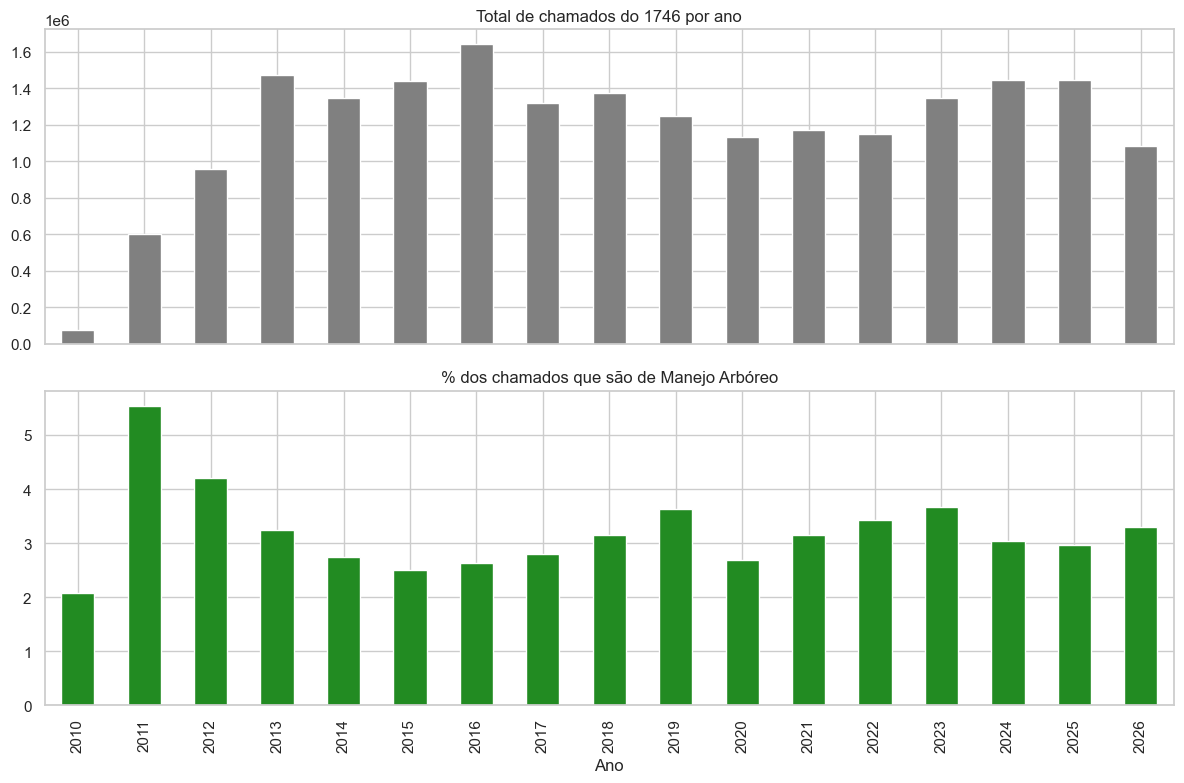

In [15]:
consulta_por_ano = """
SELECT
  EXTRACT(YEAR FROM data_inicio) AS ano,
  COUNT(*) AS total_chamados,
  COUNTIF(tipo = 'Manejo Arbóreo') AS chamados_arvore
FROM `datario.adm_central_atendimento_1746.chamado`
WHERE data_inicio IS NOT NULL
GROUP BY ano
ORDER BY ano
"""
por_ano = bd.read_sql(consulta_por_ano, billing_project_id=BILLING_PROJECT_ID)
por_ano["pct_arvore"] = 100 * por_ano["chamados_arvore"] / por_ano["total_chamados"]
display(por_ano)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
por_ano.plot(x="ano", y="total_chamados", kind="bar", ax=axes[0], color="gray", legend=False)
axes[0].set_title("Total de chamados do 1746 por ano")
por_ano.plot(x="ano", y="pct_arvore", kind="bar", ax=axes[1], color="forestgreen", legend=False)
axes[1].set_title("% dos chamados que são de Manejo Arbóreo")
axes[1].set_xlabel("Ano")
plt.tight_layout()
plt.show()

**Por que olhei o percentual?** Se o total de chamados dá um salto de um ano para o outro, pode ser que o sistema tenha mudado (um canal novo, uma migração de dados), e não que as pessoas tenham passado a reclamar mais. O percentual ajuda a separar uma coisa da outra.

No caso notamos que os chamados giram em torno de 3 a 4 % desde o ano de 2014

## 1.3 Será que existem chamados de árvore com outro "tipo"?
Estou filtrando por `tipo = 'Manejo Arbóreo'`, mas pode ter chamado sobre árvore classificado em outro tipo. Vou procurar as palavras "árvore" e "poda" no subtipo de **todos** os chamados.

In [16]:
consulta_outros_tipos = """
SELECT tipo, COUNT(*) AS chamados
FROM `datario.adm_central_atendimento_1746.chamado`
WHERE LOWER(subtipo) LIKE '%árvore%'
   OR LOWER(subtipo) LIKE '%arvore%'
   OR LOWER(subtipo) LIKE '%poda%'
GROUP BY tipo
ORDER BY chamados DESC
"""
outros_tipos = bd.read_sql(consulta_outros_tipos, billing_project_id=BILLING_PROJECT_ID)
display(outros_tipos)

Downloading: 100%|██████████|


,tipo,chamados
0,Manejo Arbóreo,601464
1,Limpeza de logradouros,65303
2,Arborização,52210
3,Danos ao meio ambiente,23505
4,Estabelecimentos Veterinários ou de interesse ...,377
5,Árvore,357
6,Árvores - Plantio,350
7,Acidentes,116
8,Desmoronamento,52
9,Semáforo,7


Apesar de manejo arbóreo ser o ponto focal do projeto notamos que podem existir ramificações, que em caso de crescimento dos número, faça sentido "olhar mais de perto" os subtipos das mesmas

## 1.4 Trazendo os chamados de árvore para o pandas (de 2021 em diante)
Para explorar coluna por coluna, vou trazer para o pandas só um pedaço da tabela:
- só chamados de **Manejo Arbóreo**;
- só de **2021 em diante** (o mesmo período que usei no primeiro notebook);
- só as **colunas que vou usar**.

In [17]:
consulta_chamados = """
SELECT
  id_chamado, data_inicio, data_fim,
  id_bairro, id_logradouro,
  categoria, subtipo,
  situacao, tipo_situacao, dentro_prazo,
  nome_unidade_organizacional
FROM `datario.adm_central_atendimento_1746.chamado`
WHERE tipo = 'Manejo Arbóreo'
  AND EXTRACT(YEAR FROM data_inicio) >= 2021
"""
chamados = bd.read_sql(consulta_chamados, billing_project_id=BILLING_PROJECT_ID)

display(chamados.head())

Downloading: 100%|██████████|


,id_chamado,data_inicio,data_fim,id_bairro,id_logradouro,categoria,subtipo,situacao,tipo_situacao,dentro_prazo,nome_unidade_organizacional
0,18807229,2023-06-13 14:37:44,2023-07-01 19:38:52,73,18580,Serviço,Poda de árvore em logradouro,Encerrado,Atendido,A Vencer (No Prazo),COMLURB - Companhia Municipal de Limpeza Urbana
1,18810491,2023-06-14 10:23:45,NaT,38,15883,Serviço,Poda de árvore em logradouro,Não Encerrado,Andamento,Vencido,COMLURB - Companhia Municipal de Limpeza Urbana
2,18793757,2023-06-09 13:22:09,2023-07-14 18:45:05,5,62349,Serviço,Poda de árvore em logradouro,Encerrado,Atendido,A Vencer (No Prazo),COMLURB - Companhia Municipal de Limpeza Urbana
3,18835129,2023-06-20 13:28:42,2023-07-12 12:49:21,144,153189,Serviço,Poda de árvore em logradouro,Encerrado,Atendido,A Vencer (No Prazo),COMLURB - Companhia Municipal de Limpeza Urbana
4,18840686,2023-06-21 14:44:49,2023-08-08 09:35:45,14,79715,Serviço,Poda de árvore em logradouro,Encerrado,Atendido,A Vencer (No Prazo),COMLURB - Companhia Municipal de Limpeza Urbana


## 1.5 Chamados por mês
Crio uma coluna com o mês de abertura e conto quantos chamados existem em cada mês.

**Cuidado que aprendi:** no primeiro notebook o gráfico despencava no final. Não era queda de demanda: os dados vão só até 20/09/2026, então setembro estava incompleto. Por isso vou tirar do gráfico o mês da última data.

Último chamado registrado: 2026-09-20 12:43:08


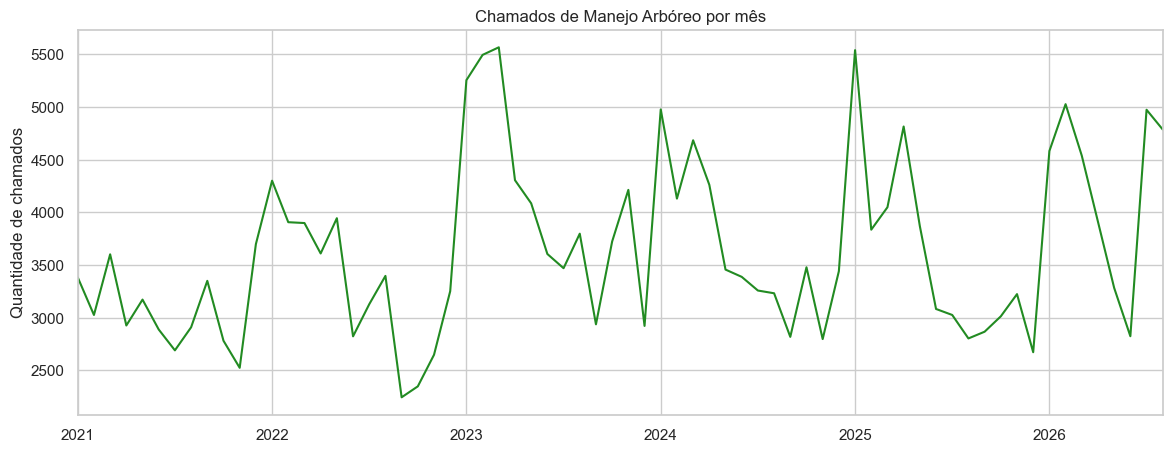

In [18]:
chamados["ano"] = chamados["data_inicio"].dt.year
chamados["mes"] = chamados["data_inicio"].dt.to_period("M")

ultima_data = chamados["data_inicio"].max()
print("Último chamado registrado:", ultima_data)

por_mes = chamados.groupby("mes").size()
por_mes = por_mes[por_mes.index < ultima_data.to_period("M")]   # tiro o último mês, que está incompleto

por_mes.plot(figsize=(14, 5), color="forestgreen")
plt.title("Chamados de Manejo Arbóreo por mês")
plt.ylabel("Quantidade de chamados")
plt.xlabel("")
plt.show()

## 1.7 Existe uma época do ano com mais chamados?
Isso se chama **sazonalidade**: um padrão que se repete todo ano. Se os chamados sobem sempre nos meses de verão, que no Rio são os mais chuvosos, é uma primeira pista para a nossa pergunta.

Coloco cada ano como uma linha no mesmo gráfico, com os meses no eixo de baixo.

ano,2021,2022,2023,2024,2025,2026
mes_do_ano,,,,,,
1,3382.0,4300.0,5255.0,4977.0,5540.0,4582.0
2,3025.0,3906.0,5495.0,4130.0,3835.0,5027.0
3,3601.0,3898.0,5567.0,4684.0,4048.0,4538.0
4,2925.0,3609.0,4305.0,4261.0,4815.0,3910.0
5,3171.0,3944.0,4085.0,3456.0,3869.0,3282.0
6,2887.0,2822.0,3604.0,3387.0,3082.0,2823.0
7,2689.0,3127.0,3469.0,3257.0,3025.0,4974.0
8,2908.0,3396.0,3797.0,3231.0,2802.0,4786.0
9,3349.0,2243.0,2936.0,2817.0,2866.0,NaN


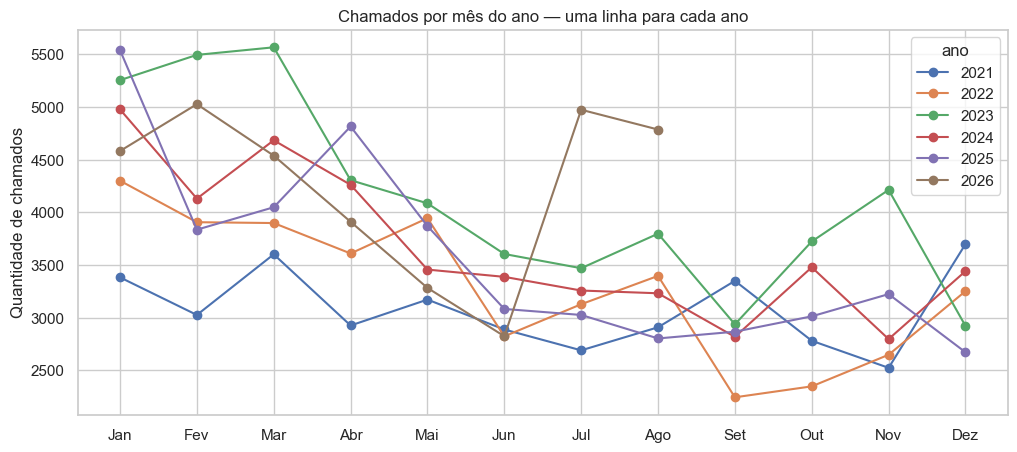

In [19]:
tabela_meses = por_mes.to_frame("chamados")
tabela_meses["ano"] = tabela_meses.index.year
tabela_meses["mes_do_ano"] = tabela_meses.index.month

sazonal = tabela_meses.pivot(index="mes_do_ano", columns="ano", values="chamados")
display(sazonal)

sazonal.plot(figsize=(12, 5), marker="o")
plt.title("Chamados por mês do ano — uma linha para cada ano")
plt.xticks(range(1, 13), ["Jan", "Fev", "Mar", "Abr", "Mai", "Jun", "Jul", "Ago", "Set", "Out", "Nov", "Dez"])
plt.xlabel("")
plt.ylabel("Quantidade de chamados")
plt.show()

NO gráfico acima é nítido a existência de uma desnidade maior de chamados no três primeiros meses do ano que começa a subir em dezembro e entra em queda após janeiro. Demonstrando a sazonalidade

## 1.8 Em que dia da semana e em que hora os chamados são abertos?
Isso ajuda a entender a rotina do serviço. Também conto quantos chamados foram abertos exatamente à meia-noite (00:00:00): se forem muitos, pode ser que a data tenha sido registrada sem o horário.

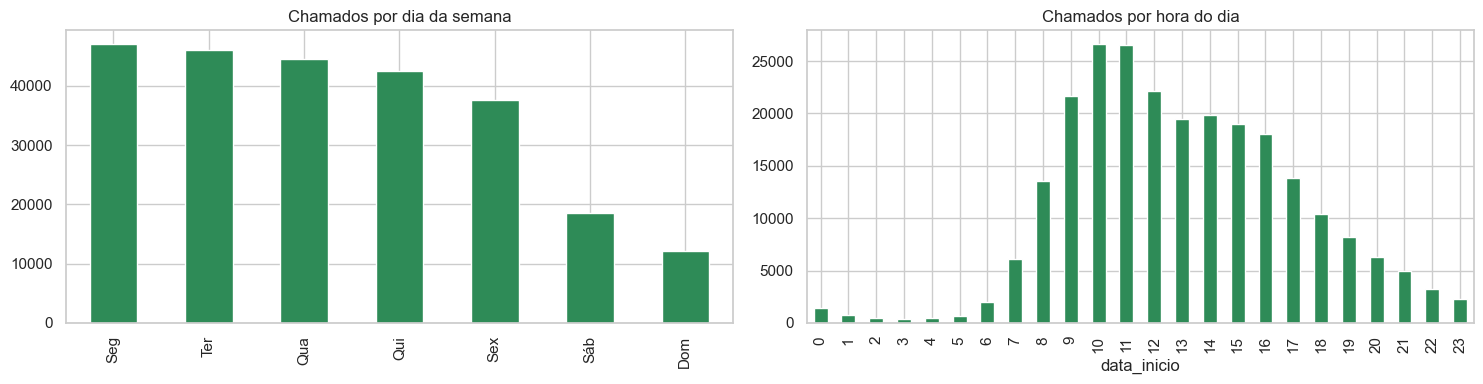

In [20]:
nomes_dias = ["Seg", "Ter", "Qua", "Qui", "Sex", "Sáb", "Dom"]
por_dia_semana = chamados["data_inicio"].dt.dayofweek.value_counts().reindex(range(7), fill_value=0)
por_dia_semana.index = nomes_dias
por_hora = chamados["data_inicio"].dt.hour.value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
por_dia_semana.plot(kind="bar", ax=axes[0], color="seagreen")
axes[0].set_title("Chamados por dia da semana")
por_hora.plot(kind="bar", ax=axes[1], color="seagreen")
axes[1].set_title("Chamados por hora do dia")
plt.tight_layout()
plt.show()

meia_noite = (chamados["data_inicio"].dt.hour == 0) & (chamados["data_inicio"].dt.minute == 0) & (chamados["data_inicio"].dt.second == 0)

## 1.9 Categorias e subtipos
A **categoria** diz que tipo de contato é (reclamação, serviço, elogio...). O **subtipo** diz qual é o serviço (poda, remoção, árvore caída...).

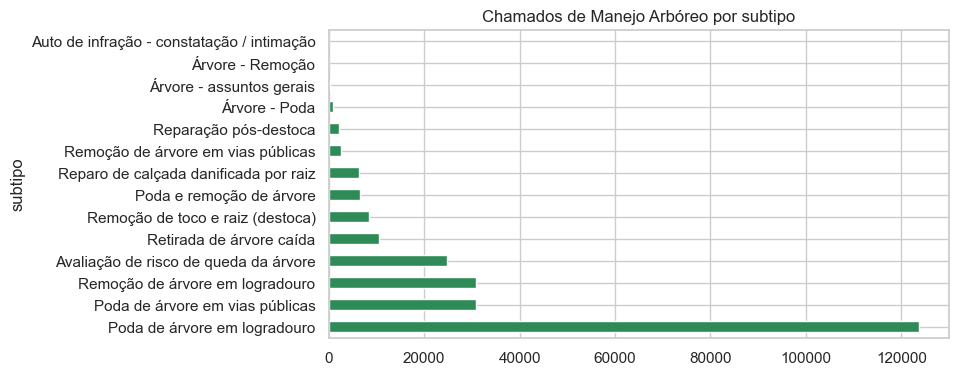

Subtipos por ano:


ano,2021,2022,2023,2024,2025,2026
subtipo,,,,,,
Auto de infração - constatação / intimação,21,8,3,0,0,0
Avaliação de risco de queda da árvore,2947,3356,4512,4462,5080,4446
Poda de árvore em logradouro,22627,24166,30482,26909,19560,0
Poda de árvore em vias públicas,718,830,679,584,6332,21780
Poda e remoção de árvore,900,1073,1227,1097,1358,870
Remoção de toco e raiz (destoca),1249,1376,2075,1701,1145,994
Remoção de árvore em logradouro,5677,5927,6655,5628,5317,1588
Remoção de árvore em vias públicas,5,8,0,0,129,2476
Reparação pós-destoca,419,507,490,258,303,162


In [21]:
chamados["subtipo"].value_counts().plot(kind="barh", color="seagreen", figsize=(8, 4))
plt.title("Chamados de Manejo Arbóreo por subtipo")
plt.show()

print("Subtipos por ano:")
display(pd.crosstab(chamados["subtipo"], chamados["ano"]))

**O que percebi:** 

Os subtipos têm nomes parecidos, de épocas diferentes (por exemplo, "Árvore - Poda" e "Poda de árvore em logradouro"). Se um nome some e outro aparece no mesmo ano, provavelmente é só **troca de nome**, não mudança na demanda. Para não me confundir, criei uma função que junta os subtipos em grupos. É uma proposta minha: preciso conferir com o grupo se faz sentido.

In [22]:

def agrupar_subtipo(subtipo):
    if pd.isna(subtipo):
        return "Sem subtipo"
    texto = subtipo.lower()
    if "caída" in texto or "caida" in texto:
        return "Árvore caída"
    elif "risco" in texto:
        return "Avaliação de risco"
    elif "calçada" in texto:
        return "Calçada danificada por raiz"   # separado da destoca (ver fase abaixo)
    elif "destoca" in texto or "toco" in texto:
        return "Destoca"
    elif "poda" in texto and "remo" in texto:
        return "Poda e remoção"
    elif "poda" in texto:
        return "Poda"
    elif "remo" in texto:
        return "Remoção"
    else:
        return "Outros"

chamados["grupo"] = chamados["subtipo"].apply(agrupar_subtipo)

fase_por_grupo = {
    "Avaliação de risco":          "Antes da queda ou remoção",
    "Poda":                        "Antes da queda ou remoção",
    "Poda e remoção":              "Antes da queda ou remoção",
    "Remoção":                     "Antes da queda ou remoção",
    "Calçada danificada por raiz": "Antes da queda ou remoção",
    "Árvore caída":                "Depois da queda ou remoção",
    "Destoca":                     "Depois da queda ou remoção",
    "Outros":                      "Não se aplica",
    "Sem subtipo":                 "Não se aplica",
}

chamados["fase"] = chamados["grupo"].map(fase_por_grupo)

# Checagem: se algum grupo ficou de fora do dicionário, ele vira NaN
print("Chamados sem fase:", chamados["fase"].isna().sum())

# Conferindo em qual fase e grupo caiu cada subtipo
display(chamados.groupby(["fase", "grupo", "subtipo"]).size().to_frame("chamados"))

Chamados sem fase: 0


chamados
fase                       grupo                       subtipo                                             
Antes da queda ou remoção  Avaliação de risco          Avaliação de risco de queda da árvore          24803
                           Calçada danificada por raiz Reparo de calçada danificada por raiz           6424
                           Poda                        Poda de árvore em logradouro                  123744
                                                       Poda de árvore em vias públicas                30923
                                                       Árvore - Poda                                    828
                           Poda e remoção              Poda e remoção de árvore                        6525
                           Remoção                     Remoção de árvore em logradouro                30792
                                                       Remoção de árvore em vias públicas              2618
                                                       Árvore - Remoção                                 162
Depois da queda ou remoção Destoca                     Remoção de toco e raiz (destoca)                8540
                                                       Reparação pós-destoca                           2139
                           Árvore caída                Retirada de árvore caída                       10591
Não se aplica              Outros                      Auto de infração - constatação / intimação        32
                                                       Árvore - assuntos gerais                         230

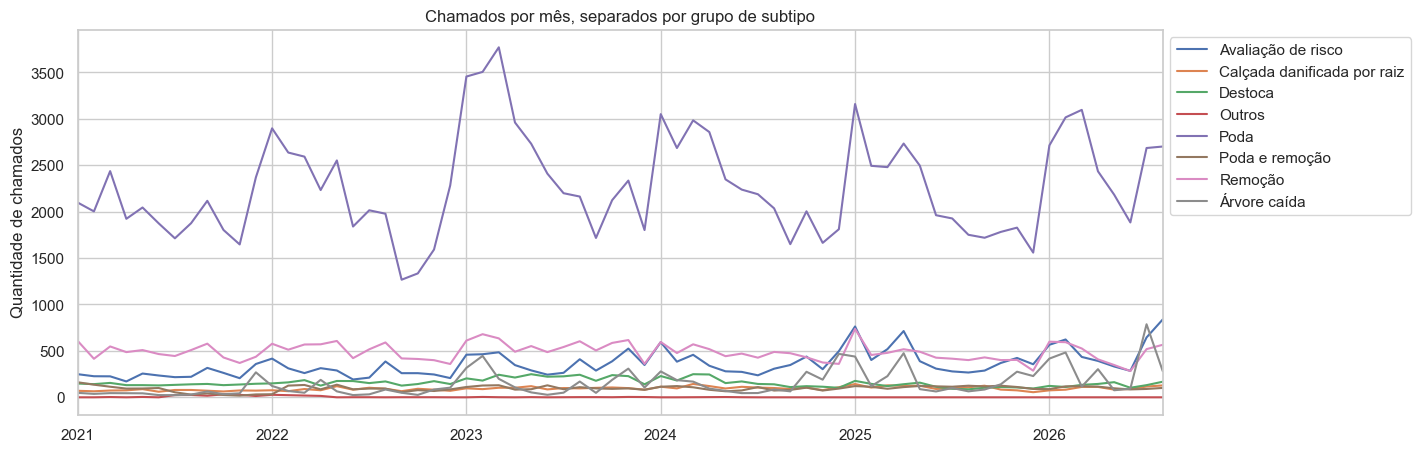

In [23]:
grupo_por_mes = chamados.groupby(["mes", "grupo"]).size().unstack(fill_value=0)
grupo_por_mes = grupo_por_mes[grupo_por_mes.index < ultima_data.to_period("M")]

grupo_por_mes.plot(figsize=(14, 5))
plt.title("Chamados por mês, separados por grupo de subtipo")
plt.ylabel("Quantidade de chamados")
plt.xlabel("")
plt.legend(bbox_to_anchor=(1, 1))
plt.show()

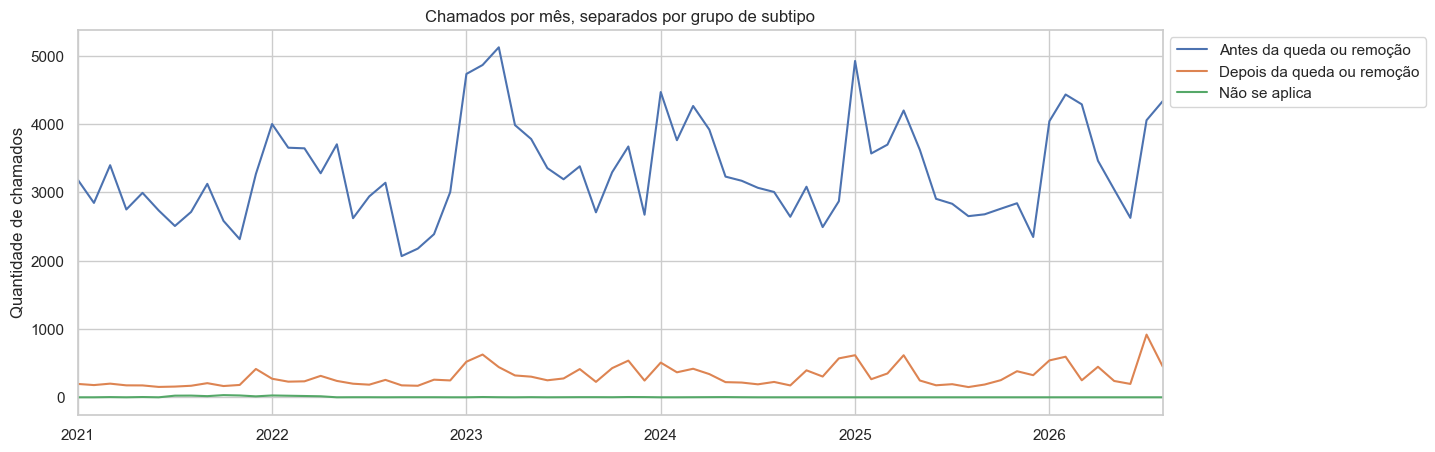

In [24]:
grupo_por_mes = chamados.groupby(["mes", "fase"]).size().unstack(fill_value=0)
grupo_por_mes = grupo_por_mes[grupo_por_mes.index < ultima_data.to_period("M")]

grupo_por_mes.plot(figsize=(14, 5))
plt.title("Chamados por mês, separados por grupo de subtipo")
plt.ylabel("Quantidade de chamados")
plt.xlabel("")
plt.legend(bbox_to_anchor=(1, 1))
plt.show()

## 1.10 Onde: bairro e logradouro
Nas primeiras celulas desse notebook notamoas uma quantidade consideravel de chamados sem nenhuma informação relacionada a localização, mais posteriormente apóso tratamento tais informações devem ser desconsideradas.

Tal ação deve-se ao fato da pesquisa estar diretamente relacionada a fatores de localidade.

,sem_bairro,sem_logradouro
ano,,
2021,3.58,3.58
2022,3.17,3.17
2023,2.47,2.47
2024,3.90,3.90
2025,2.34,2.34
2026,0.61,0.61


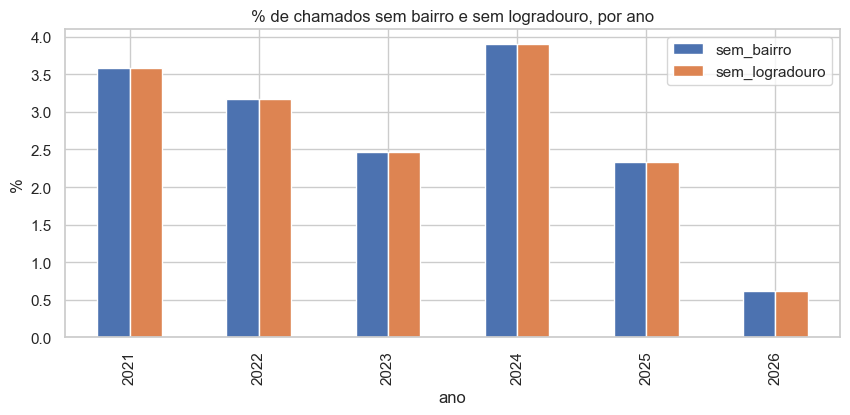

Bairros (por id) com mais chamados:


id_bairro
144    20719
33      9252
141     7499
132     6528
122     6292
139     6013
128     5747
149     5083
151     4126
36      3946
Name: count, dtype: int64

In [25]:
chamados["sem_bairro"] = chamados["id_bairro"].isnull()
chamados["sem_logradouro"] = chamados["id_logradouro"].isnull()

sem_localizacao = chamados.groupby("ano")[["sem_bairro", "sem_logradouro"]].mean() * 100
display(sem_localizacao.round(2))

sem_localizacao.plot(kind="bar", figsize=(10, 4))
plt.title("% de chamados sem bairro e sem logradouro, por ano")
plt.ylabel("%")
plt.show()

print("Bairros (por id) com mais chamados:")
display(chamados["id_bairro"].value_counts().head(10))

Por enquanto só tenho o **número** do bairro (`id_bairro`). Os nomes estão em outra tabela, que vou juntar na seção 5.

## 1.11 Situação e prazo
`situacao` diz se o chamado foi encerrado. `dentro_prazo` diz se o atendimento cumpriu o prazo.

Situação:


situacao
Encerrado        206942
Não Encerrado     41409
Name: count, dtype: int64

ano,2021,2022,2023,2024,2025,2026
situacao,,,,,,
Encerrado,29141,30363,44867,40230,36811,25530
Não Encerrado,7797,9127,4503,3685,5977,10320


Situação x prazo:


dentro_prazo,A Vencer (No Prazo),Em Vencimento (No Prazo),Não Calculado,Pendente de Programação,Vencido
situacao,,,,,
Encerrado,95898,80072,11395,7,19570
Não Encerrado,17907,827,3400,15490,3785


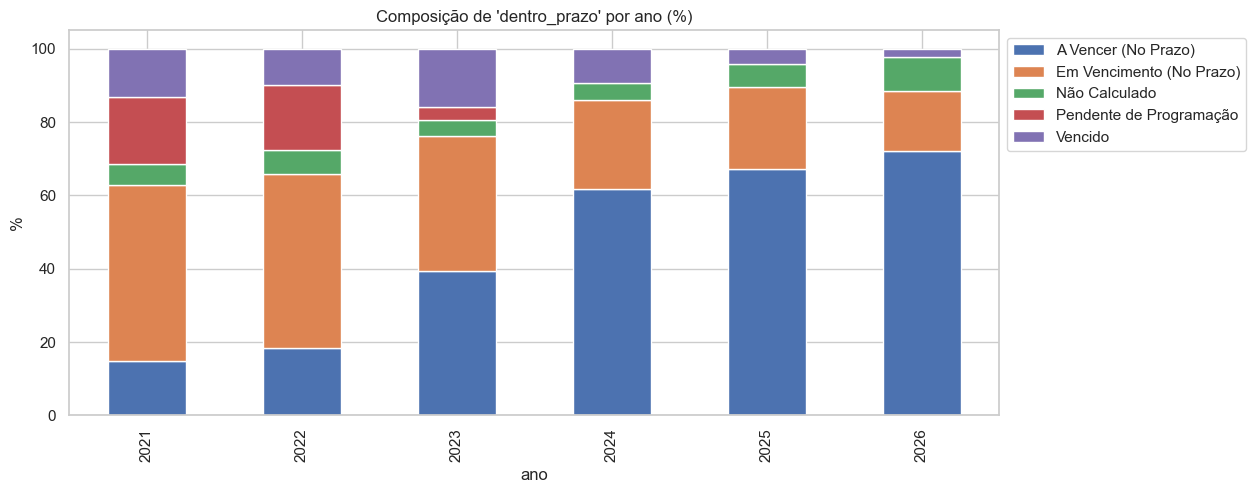

In [26]:
print("Situação:")
display(chamados["situacao"].value_counts())


display(pd.crosstab(chamados["situacao"], chamados["ano"]))

print("Situação x prazo:")
display(pd.crosstab(chamados["situacao"], chamados["dentro_prazo"]))

prazo_por_ano = pd.crosstab(chamados["ano"], chamados["dentro_prazo"], normalize="index") * 100
prazo_por_ano.plot(kind="bar", stacked=True, figsize=(12, 5))
plt.title("Composição de 'dentro_prazo' por ano (%)")
plt.ylabel("%")
plt.legend(bbox_to_anchor=(1, 1))
plt.show()

Notamos uma possivel melhor no atendimento ao decorrer dor anos, devido ao fato do tipo "Em Vencimento" (No Prazo) diminuir e o "A vencer (No Prazo)"aumentar. Entretnato, indica que há uma grande quantidade de chamados para serem resolvidos em 2026, sendo assim necessário um entendimento de qual priorizar.

## 1.12 Quanto tempo leva para fechar um chamado?
Subtraio a data de abertura da data de encerramento e transformo o resultado em dias.

Chamados sem data de encerramento: 41418

Mediana de dias para fechar, por ano:


ano
2021    28.9
2022    21.4
2023    15.9
2024    13.9
2025    11.2
2026     5.8
Name: dias_para_fechar, dtype: float64

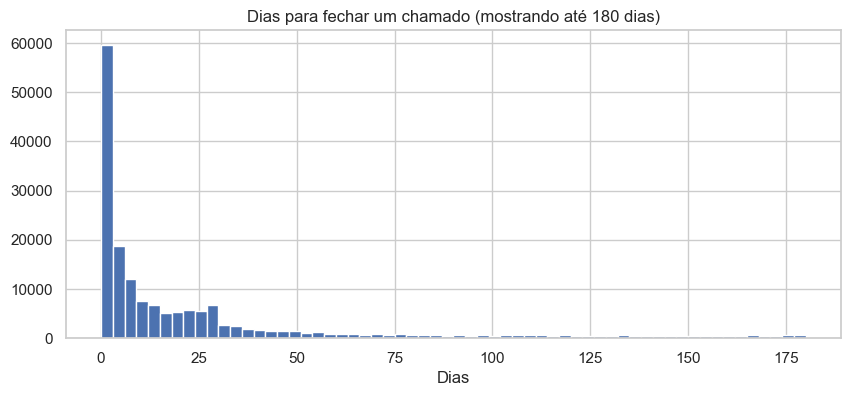

In [27]:
chamados["dias_para_fechar"] = (chamados["data_fim"] - chamados["data_inicio"]).dt.total_seconds() / 86400

print("Chamados sem data de encerramento:", chamados["data_fim"].isnull().sum())

print("\nMediana de dias para fechar, por ano:")
display(chamados.groupby("ano")["dias_para_fechar"].median().round(1))

chamados.loc[chamados["dias_para_fechar"].between(0, 180), "dias_para_fechar"].hist(bins=60, figsize=(10, 4))
plt.title("Dias para fechar um chamado (mostrando até 180 dias)")
plt.xlabel("Dias")
plt.show()

Usei a **mediana** em vez da média porque alguns chamados demoram muito e puxam a média para cima.

Agora vejo se existem horários de encerramento repetidos muitas vezes, como aqueles da SEOP que vi na amostra. Quando centenas de chamados fecham no mesmo segundo, provavelmente foi uma baixa feita em lote no sistema, e o "tempo para fechar" desses chamados não é real.

In [28]:
print("Horários de encerramento que mais se repetem:")
display(chamados["data_fim"].value_counts().head(10))

Horários de encerramento que mais se repetem:


data_fim
2025-10-14 16:22:37    83
2025-10-14 16:22:41    69
2025-10-14 16:22:38    67
2025-10-13 16:58:37    52
2025-10-13 16:58:35    45
2025-10-13 16:58:21    42
2025-10-13 16:58:34    40
2025-10-13 16:58:36    39
2025-10-13 16:58:20    38
2025-10-13 16:57:07    38
Name: count, dtype: int64

## 1.13 O que aprendi sobre os chamados
- Desde 2021, os chamados de árvore sobem no **começo do ano** (verão, época de chuva) e caem no segundo semestre. É uma pista a favor da hipótese da chuva, mas ainda não é prova. Julho e agosto de 2026 fugiram do padrão, com volume alto: vale procurar se houve algum temporal nesse período.
- No histórico completo, **72.626 chamados de árvore estão sem bairro** (no primeiro notebook eles apareciam como "None" no topo do ranking).
- Nem toda categoria é pedido de serviço (tem Elogio, Crítica, Sugestão).
- Os subtipos mudaram de nome ao longo do tempo, então é melhor analisar por grupo.

**Para preencher depois de rodar:** quantos chamados de árvore estão em outros tipos (1.3), se há `id_chamado` repetido (1.5), o que os gráficos de sazonalidade mostraram (1.7) e se existem fechamentos em lote (1.12).

## 1.14 Salvando os dados para os próximos notebooks
Salvo os chamados desde 2021 (com as colunas que criei, como `grupo`, `fase` e `dias_para_fechar`) e a contagem mensal, que o notebook `04_cruzamentos.ipynb` vai usar.

Salvo em **parquet** em vez de CSV porque esse formato guarda o tipo de cada coluna (datas continuam sendo datas) e ocupa menos espaço. A pasta `data/processed/` fica fora do Git: os arquivos são recriados sempre que o notebook roda.

In [29]:
from pathlib import Path

PASTA_PROCESSED = Path("../data/processed")
PASTA_PROCESSED.mkdir(parents=True, exist_ok=True)

# "mes" é do tipo Period, específico do pandas. Como ela sai de data_inicio, deixo de fora.
chamados.drop(columns=["mes"]).to_parquet(PASTA_PROCESSED / "chamados_manejo_2021.parquet", index=False)

# Pelo mesmo motivo, guardo cada mês como uma data (o dia 1 do mês)
por_mes.to_timestamp().to_frame("chamados").to_parquet(PASTA_PROCESSED / "chamados_por_mes.parquet")

print("Arquivos salvos em:", PASTA_PROCESSED.resolve())

Arquivos salvos em: C:\Users\VitorCoutoFilho\OneDrive - Urca Energia Participações Ltda\Documentos\Vitor Couto Filho\data\processed
